#  Question 1: Descriptive Statistics with NumPy

### Task: 
* Load the Data: Use the dataset csv given. 
* Load the file using NumPy, making sure to skip the header row and unpack the columns into variables hours and scores.
* Calculate the following for the Scores column:
* The arithmetic mean.The unbiased standard deviation (using $n-1$ degrees of freedom).
* The Interquartile Range (IQR) by finding the 25th and 75th percentiles.
* Output: Print the results rounded to two decimal places. Use round() built-in function to roundof the values.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

hours, scores = np.loadtxt('studentscores.csv', delimiter=',', skiprows=1, unpack=True)

print('Hours::', hours)
print('Scores::', scores)

print('Mean of scores is {}'.format(round(np.mean(scores), 2)))
print('The unbiased standard deviation using n-1 degrees of freedom is {}'.format(round(np.std(scores, ddof=1), 2)))
print('25th percentile of scores is {}'.format(round(np.percentile(scores, 25), 2)))
print('75th percentile of scores is {}'.format(round(np.percentile(scores, 75), 2)))
print('The inquartile Range (IQR) by finding the 25th and 75th percentile is {}'.format(round(np.percentile(scores, 75) - np.percentile(scores, 25), 2)))


Hours:: [2.5 5.1 3.2 8.5 3.5 1.5 9.2 5.5 8.3 2.7 7.7 5.9 4.5 3.3 1.1 8.9 2.5 1.9
 6.1 7.4 2.7 4.8 3.8 6.9 7.8]
Scores:: [21. 47. 27. 75. 30. 20. 88. 60. 81. 25. 85. 62. 41. 42. 17. 95. 30. 24.
 67. 69. 30. 54. 35. 76. 86.]
Mean of scores is 51.48
The unbiased standard deviation using n-1 degrees of freedom is 25.29
25th percentile of scores is 30.0
75th percentile of scores is 75.0
The inquartile Range (IQR) by finding the 25th and 75th percentile is 45.0


# Q2. Plotting an Empirical PDF

### Task :
1. Prepare Data: Using the scores NumPy array from Question 1, create a histogram using plt.hist with density=True and bins='auto' to show the probability density of the scores.
2. Add Mean Marker: Use plt.axvline to add a vertical dashed line that indicates the mean score on the x-axis.

    * Note: We use a vertical line because the scores are plotted along the horizontal (x) axis; a vertical line allows us to point exactly to the mean's location.
3. Display: Add appropriate labels for the x-axis ("Scores") and y-axis ("Probability Density") and show the plot.
4. Use plt.show() to render the final plot.

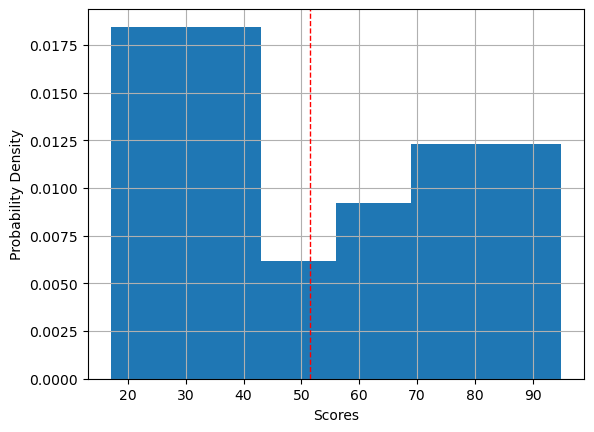

In [10]:
plt.hist(scores, density=True, bins='auto')
plt.axvline(np.mean(scores), color='red', label='Mean', linestyle='dashed', linewidth=1)
plt.grid()
plt.xlabel('Scores')
plt.ylabel('Probability Density')
plt.show()

# Q3 Analyzing Correlation visually

### Task:
 1.  Calculate the Pearson correlation coefficient ($r$) between Hours and Scores.
 2.  Generate a scatter plot where the size of each point increases based on how far that student's score is from the mean (use the squared difference as the size).
 3. Output: Display the plot with the correlation coefficient $r$ included in the title.

Text(0.5, 1.0, 'Correlation Coefficient r=0.98')

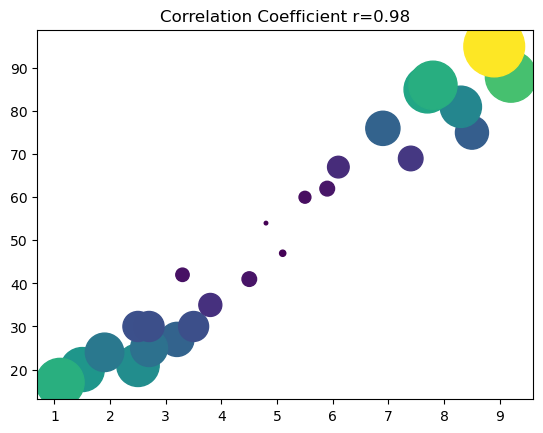

In [14]:
r = np.corrcoef(hours, scores)[0, 1]
s = (hours - np.mean(hours))**2 + (scores - np.mean(scores))**2
plt.scatter(hours, scores, c=s, s=s)
plt.title('Correlation Coefficient r={}'.format(round(r, 2)))

# Q4. Probability Analysis of Student Performance

### Scenario: You are analyzing a group of students to understand how likely they are to achieve high marks. In class, the professor demonstrated how to load external data using np.loadtxt and how to create an empirical Cumulative Distribution Function (CDF) using np.histogram and np.cumsum.
Task: 

* Define a CDF Function: Write a function calc_cdf(data) that returns the bins and the cumulative probability array.
* Analyze Thresholds: Using your CDF, calculate the probability that a student scores 80 or more.
* Output: Print the probability as a percentage (e.g., $15.00\%$).
* (Hint: Remember that the CDF at value $x$ gives you $P(X \le x)$. To find $P(X \ge x)$, you should use the complement rule: $1 - P(X < x)$.)

In [ ]:
def calc_cdf(data):
    counts, bins = np.histogram(data, bins='auto')
    probabilities = counts / len(data)
    cum_prob = np.cumsum(probabilities)
    return bins, cum_prob

bins, cum_prob = calc_cdf(scores)

idx = np.searchsorted(bins, 80) - 1

if idx >= 0 and idx < len(cum_prob):
    prob_less_than_80 = cum_prob[idx]
else:
    prob_less_than_80 = cum_prob[-1]

prob_80_or_more = 1 - prob_less_than_80
print('Probability of scoring less than 80 is {}'.format(round(prob_80_or_more*100, 2)))


Probability of scoring less than 80 is 16.0


# Q5. Functions, Loops, and Abstraction

### Without using NumPy or any external libraries, perform the following tasks :
Perform:
* Format Conversion: Convert your hours and scores NumPy arrays into standard Python lists using list(hours) and list(scores).
* Generate Predictions: Create a new list called predicted_scores based on the rule: $Score = 9.77 \times Hours$.
* Pure Python Logic: Without using NumPy, write two functions:

    1. custom_mean(lst): Calculates the mean of a list using a for loop.

    2. calculate_mse(actual, predicted): Iterates through both lists using zip, calculates the squared differences, and uses custom_mean to return the Mean Squared Error (MSE).
* Output: Print the MSE of this simple linear prediction model.




In [28]:
list_hours = hours.tolist()
list_scores = scores.tolist()

list_predicted_scores = []

for i in list_hours:
    predicted_score = 9.77 * i
    list_predicted_scores.append(predicted_score)

print(list_predicted_scores)

def custom_mean(data):
    return sum(data) / len(data)

def calculate_mse(actual, predicted):
    mse = sum((a - p) ** 2 for a, p in zip(actual, predicted)) / len(actual)
    return mse

print(custom_mean(list_scores))
print(calculate_mse(list_scores, list_predicted_scores))

[24.424999999999997, 49.82699999999999, 31.264, 83.045, 34.195, 14.655, 89.88399999999999, 53.735, 81.09100000000001, 26.379, 75.229, 57.643, 43.964999999999996, 32.241, 10.747, 86.953, 24.424999999999997, 18.563, 59.596999999999994, 72.298, 26.379, 46.895999999999994, 37.126, 67.413, 76.20599999999999]
51.48
35.19689948000001
